In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [117]:
RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')


In [2]:
RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')


In [3]:
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')


In [118]:
RP506=xr.concat([RP506,RP5062,RP5063],dim='time')


In [119]:
ME506=xr.concat([ME506,ME5062,ME5063],dim='time')


In [123]:
RP506=RP506[['LHFX','SWGNET','SHFX', 'TA', 'TS']].sel(time=slice('2005-05-06','2005-07-02')).compute()

In [7]:
# RP506=RP506[['LSPRCP','CNPRCP','EVAP','PRECTOT','EVAPOUT']].sel(time=slice('2005-05-06','2005-07-02')).compute()

In [8]:
# RP506P=(RP506.PRECTOT.compute())*86400
# RP506L=(RP506.LHFX.compute())#*86400


In [124]:
ME506=ME506[['LHFX','SWGNET','SHFX', 'TA', 'TS']].sel(time=slice('2005-05-06','2005-07-02')).compute()

In [181]:
ME506L=(ME506.SHFX.compute())#*86400
RP506L=(RP506.SHFX.compute())
    

In [167]:
ME506L=(-ME506.SWGNET+ME506.SHFX).compute()
RP506L=(-RP506.SWGNET+RP506.SHFX).compute()

In [150]:
ME506L=(ME506.TS-ME506.TA).compute()
RP506L=(RP506.TS-RP506.TA).compute()

In [182]:
d=8

ME506L=ME506L[d:]-ME506L.data[:-d]
RP506L=RP506L[d:]-RP506L.data[:-d]

In [178]:
ME506L=ME506L.resample(time='1D').mean()
RP506L=RP506L.resample(time='1D').mean()

In [183]:
ticks=[]

for i in range(len(ME506L.time)):
    ticks=append(ticks,str(ME506L.time.data[i])[5:10])

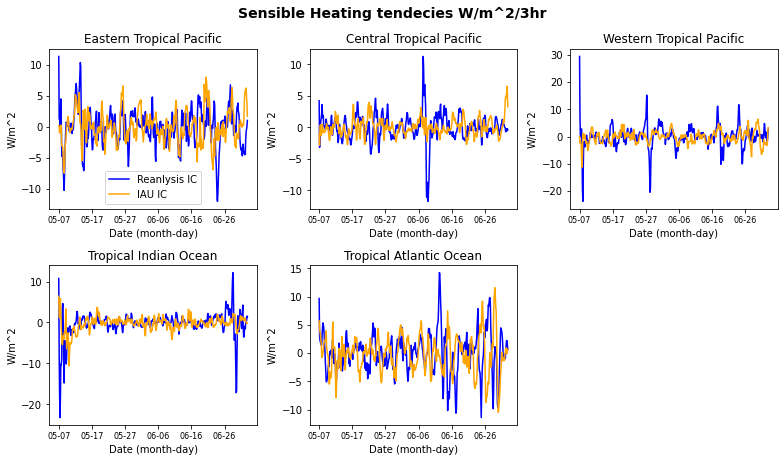

In [191]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')

x1=90
x2=91
y1=23
y2=25

# plt.subplot(2,3,6)
# # plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# # plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# #plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# #plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# plt.title('Indian Monsoon')
# plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
# plt.xlabel('Date (month-day)')
# plt.ylabel('W/m^2')

# x1=32
# x2=35
# y1=-1
# y2=2


plt.suptitle('Sensible Heating tendecies W/m^2/3hr', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('/nobackupp27/afahad/scripts/initialization_shock/spike_SHFX.png',dpi=150)

NameError: name 'ME506P' is not defined

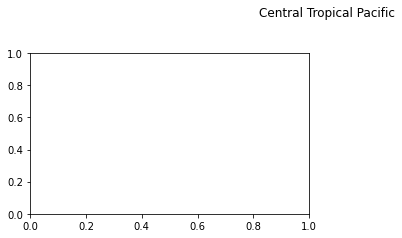

In [141]:

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)

x1=-178
x2=-178
y1=2
y2=2

plt.suptitle('Central Tropical Pacific')

plt.subplot(2,2,1)

plt.plot((ME506P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Total Precip')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


plt.subplot(2,2,2)

plt.plot((ME506C).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506C).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Convective Precip')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

plt.subplot(2,2,3)

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Large Scale Precip')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


plt.subplot(2,2,4)

plt.plot((ME506E).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506E).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Evaporation')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)

In [ ]:
ticks=[]

for i in range(len(ME506U.time)):
    ticks=append(ticks,str(ME506U.time.data[i])[5:10])

In [ ]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=90
x2=91
y1=23
y2=25

plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


plt.plot((RP506U).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=32
x2=35
y1=-1
y2=2



plt.tight_layout()
plt.savefig('spike_T10.png',dpi=150)

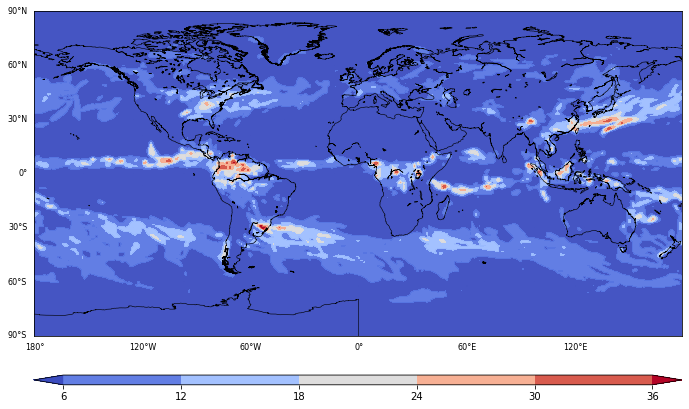

In [28]:
f()
plot(ME426P.std(dim='time'));

In [31]:
ME416L=(ME416.LHFX.compute())
ME421L=(ME421.LHFX.compute())
ME426L=(ME426.LHFX.compute())

In [93]:
ME506L=(ME506.LHFX.compute())
RP506L=(RP506.LHFX.compute())

In [95]:
ME426L=(ME426.LHFX.compute())
RP426L=(RP426.LHFX.compute())

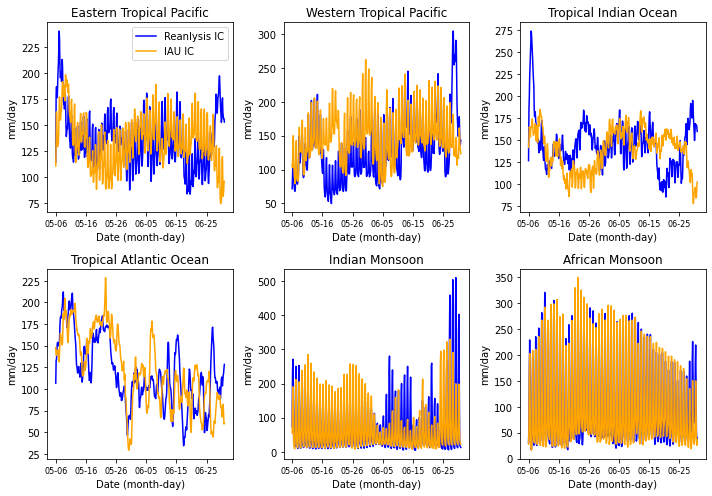

In [94]:
x1=87
x2=99
y1=9
y2=10

plt.figure(figsize=(10,7))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=39
x2=41
y1=-6
y2=-4

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=89
x2=92
y1=9
y2=10



plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=-39
x2=-38
y1=9
y2=10



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=90
x2=91
y1=23
y2=25

plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=32
x2=35
y1=-1
y2=2

plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506L).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('African Monsoon')
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')
plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)

In [99]:
ME=ME426L.std(dim='time')
RP=RP426L.std(dim='time')

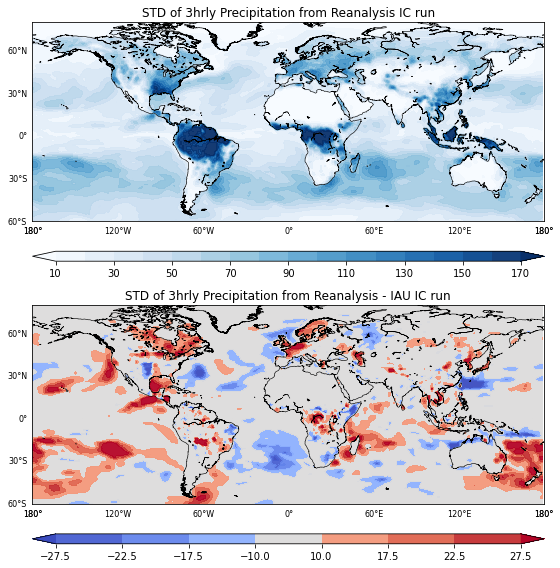

In [107]:
plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plot(ME,clf=arange(1,18)*10,cmap='Blues',lon1=-180,lon2=180,lat1=-60,lat2=80);
plt.title('STD of 3hrly Precipitation from Reanalysis IC run')
plt.subplot(2,1,2)
plot(ME-RP,clf=array([-11,-9,-7,-4,4,7,9,11])*2.5,lon1=-180,lon2=180,lat1=-60,lat2=80);
plt.title('STD of 3hrly Precipitation from Reanalysis - IAU IC run')
plt.tight_layout()
#plt.savefig('pr_std.png',dpi=150)

In [20]:
rp=xr.open_dataset('/nobackupp27/afahad/exp/GEOSMIT_RP0416/holding/geosgcm_prog/200505/GEOSMIT_RP0416.geosgcm_prog.monthly.200505.nc4')
me=xr.open_dataset('/nobackupp27/afahad/exp/GEOSMIT_ME0416/holding/geosgcm_prog/200505/GEOSMIT_ME0416.geosgcm_prog.monthly.200505.nc4')

In [35]:
(me.P-rp.P).mean(dim='lon').sel(lev=slice(1000,200)).plot(levels=arange(-2,2.1,.25),extend='both')
plt.gca().invert_yaxis()

AttributeError: 'Dataset' object has no attribute 'P'

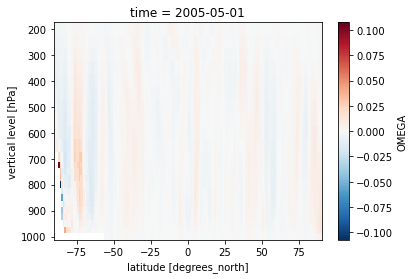

In [37]:
(me.OMEGA-rp.OMEGA).mean(dim='lon').sel(lev=slice(1000,200)).plot()
plt.gca().invert_yaxis()

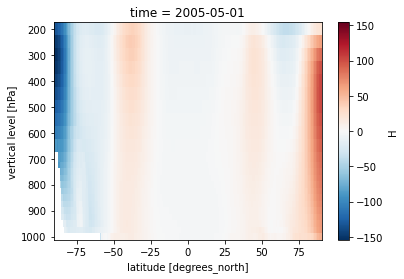

In [38]:
(me.H-rp.H).mean(dim='lon').sel(lev=slice(1000,200)).plot()
plt.gca().invert_yaxis()

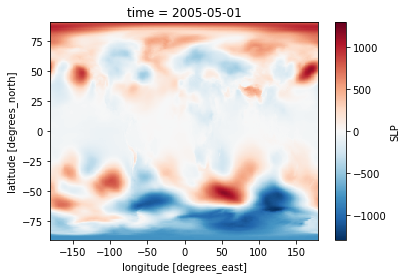

In [41]:
(me.SLP-rp.SLP).plot()

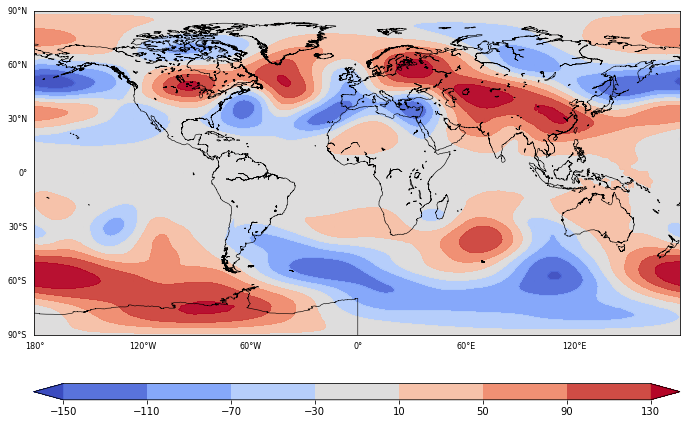

In [50]:
f();
plot(squeeze((me.H-me.H.mean(dim='lon')).sel(lev=200)),clf=arange(-150,151,40));

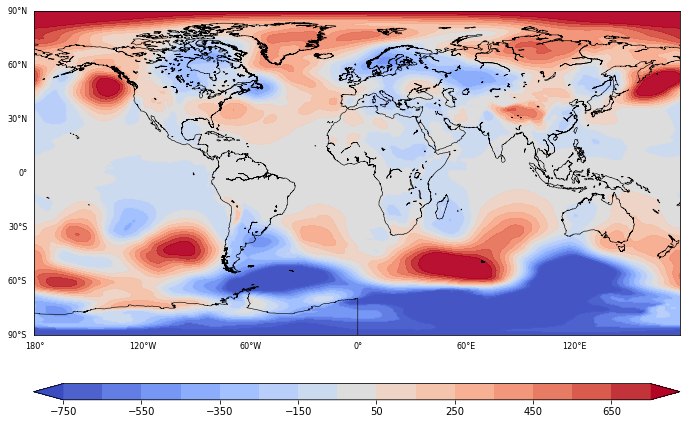

In [58]:
f();
plot(squeeze((me.SLP-rp.SLP)),clf=arange(-150,151,20)*5);

In [59]:
rp=xr.open_dataset('/nobackupp27/afahad/exp/GEOSMIT_RP0416/holding/geosgcm_surf/200505/GEOSMIT_RP0416.geosgcm_surf.monthly.200505.nc4')
me=xr.open_dataset('/nobackupp27/afahad/exp/GEOSMIT_ME0416/holding/geosgcm_surf/200505/GEOSMIT_ME0416.geosgcm_surf.monthly.200505.nc4')

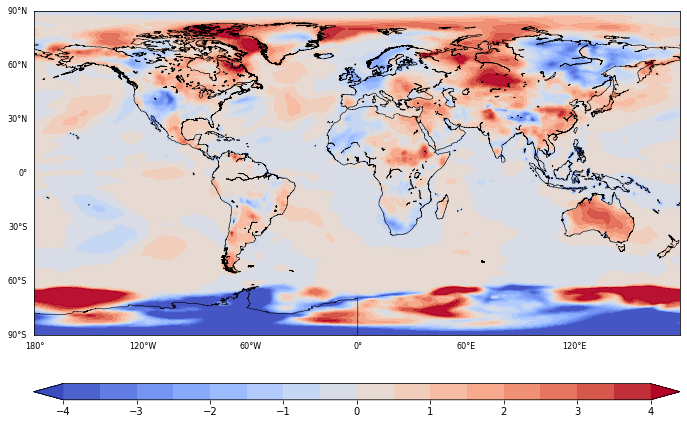

In [62]:
f();
plot(squeeze((me.TS-rp.TS)),clf=arange(-4,4.1,.5));

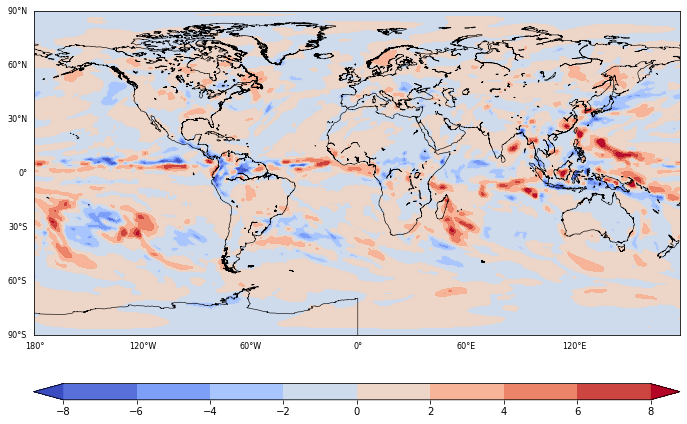

In [69]:
f();
plot(squeeze((me.PRECTOT-rp.PRECTOT)*86400),clf=arange(-8,8.1,2));

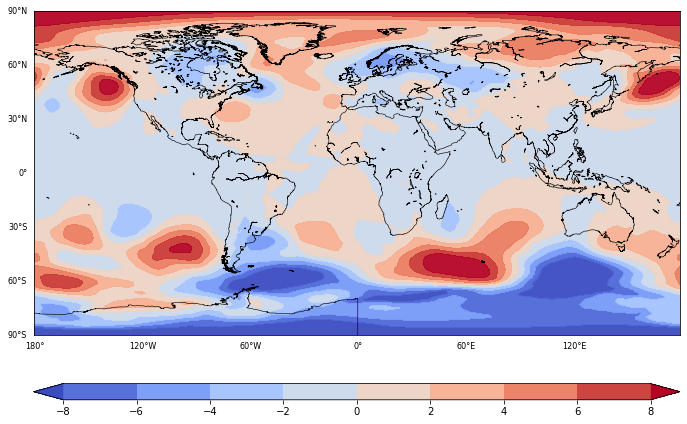

In [72]:
f();
plot(squeeze((me.PS-rp.PS)/100),clf=arange(-8,8.1,2));

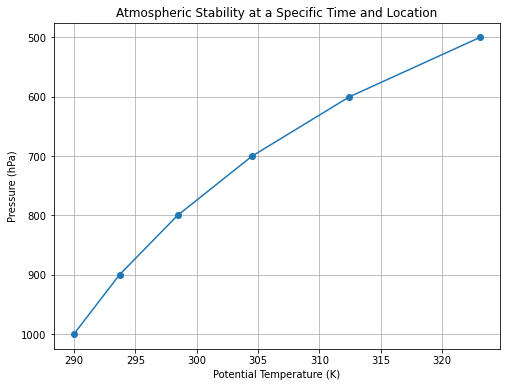

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Assume you have your data in these variables:
#   - temperature: Array of temperatures at different levels (in K)
#   - pressure: Array of pressure levels (in hPa)
#   - dewpoint: Array of dew point temperatures at different levels (in C) - Optional
#   - altitude: Array of altitudes corresponding to the levels (in m or km) - Optional

# Example placeholder data (replace with your actual data)
pressure = np.array([1000, 900, 800, 700, 600, 500])  # hPa
temperature = np.array([290, 285, 280, 275, 270, 265])  # K
dewpoint = np.array([15, 12, 10, 8, 6, 4])  # °C
altitude = np.array([0, 1, 2, 3, 4, 5])  # km

# --- Constants ---
P0 = 1000  # Reference pressure (hPa)
R = 287  # Gas constant for dry air (J/(kg*K))
Cp = 1004  # Specific heat capacity of dry air at constant pressure (J/(kg*K))

# --- Calculations ---

# 1. Potential Temperature
theta = temperature * (P0 / pressure)**(R / Cp)

#2.  Calculate Dew point and vapor pressure if needed

# 3. (Optional) Virtual Potential Temperature (Approximation)
# You'll need to calculate the mixing ratio (w) first, which requires more complex calculations.
# For a rough estimate, you might skip this if the air is not very moist.
# theta_v = theta * (1 + 0.61 * w)

# --- Plotting ---
plt.figure(figsize=(8, 6))

# Plot potential temperature vs. pressure
plt.plot(theta, pressure, marker='o', linestyle='-')
plt.gca().invert_yaxis()  # Invert y-axis to show pressure decreasing upwards
plt.xlabel("Potential Temperature (K)")
plt.ylabel("Pressure (hPa)")
plt.title("Atmospheric Stability at a Specific Time and Location")
plt.grid(True)

# Or, if you have altitude data:
# plt.plot(theta, altitude, marker='o', linestyle='-')
# plt.xlabel("Potential Temperature (K)")
# plt.ylabel("Altitude (km)")
# plt.title("Atmospheric Stability at a Specific Time and Location")
# plt.grid(True)

# (Optional) Add a second line for virtual potential temperature if calculated
# plt.plot(theta_v, pressure, marker='x', linestyle='--', label="Virtual Potential Temperature")
# plt.legend()

plt.show()

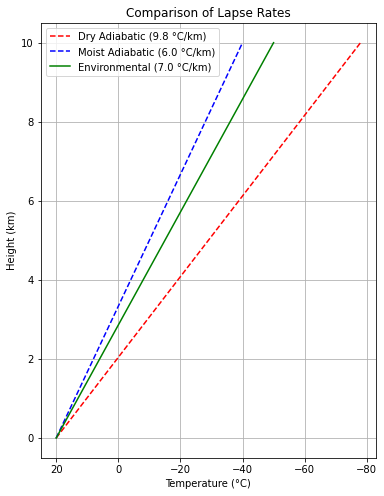

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# 1. Define parameters
# ------------------------
z_max = 10.0          # Maximum height (km)
dz = 0.1              # Height increment (km)
z = np.arange(0, z_max + dz, dz)  # Height levels from 0 to z_max

# Set a reference surface temperature (°C) at z=0
T0 = 20.0

# Lapse rates (°C per km)
DALR = 9.8            # Dry Adiabatic Lapse Rate
MALR = 6.0            # Moist Adiabatic Lapse Rate (typical average)
ELR  = 7.0            # Environmental Lapse Rate (example)

# ------------------------
# 2. Compute temperature profiles
# ------------------------
T_dry  = T0 - DALR * z
T_moist = T0 - MALR * z
T_env   = T0 - ELR  * z

# ------------------------
# 3. Plot the results
# ------------------------
plt.figure(figsize=(6, 8))

# Plot each temperature profile vs. height
plt.plot(T_dry,   z, label='Dry Adiabatic (9.8 °C/km)', color='red',   linestyle='--')
plt.plot(T_moist, z, label='Moist Adiabatic (6.0 °C/km)', color='blue',  linestyle='--')
plt.plot(T_env,   z, label='Environmental (7.0 °C/km)', color='green')

plt.gca().invert_xaxis()  # Often skew-T-like plots have temperature decreasing to the left
plt.xlabel('Temperature (°C)')
plt.ylabel('Height (km)')
plt.title('Comparison of Lapse Rates')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [154]:
pwd

'/nobackupp27/afahad/scripts/initialization_shock'